# Solution closeness assessment
Let us take an ODE $E(f)$ with multiple solutions $f_i$. Let us call a first, known, non-trivial reference solution, called $f_0$. We approximate this function using a Neural Network $n_0$. We can compute two metrics: (i) the error between samples of $f_0$ and $n_0$, and the residual error on $e_0 = E(n_0)$. Then, we solve $E$ using a classical PINN optimization. We get a second solution, under the form of a Neural Network, say, $n_1$, and we have, by construction, the residual error $e_1 = E(n_1)$. The question is: generally speaking, are $e_0$ and $e_1$ of the same order of magnitude ?

## Simple Integrator
Let us take the equation
$$y''(x) = k^2y(x)$$

We know that the solutions are of the form $f_i = c_1 e^{kx} + c_2 e^{-kx}$. For the rest of this experiment, we fix $k=2$:

In [12]:
k = 2.

We import common libraries:

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from torchsummary import summary
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

In [14]:
device = 'mps'

### Neural Network
First, we build the network structure. To avoid a the trivial null solution, we can, by design, enforce boundary conditions. This has to be discussed later.

In [4]:
class NetworkBC(nn.Module):
    def __init__(self, width=16):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        
    def forward(self, x):
        return self.l1(x) * (x**2 - 1) + 1

We define a loss function for training a first Neural Network $n_0$ that approximates a known solution $f$ (that corresponds to the chosen boundary conditions:)

In [5]:
def loss_fn(y_hat, y):
    return torch.mean((y_hat-y)**2)

And we define this solution $f$. In the rest, we use `f2(x)`.

In [6]:
def f0(x):
    return torch.exp(k*x)

def f1(x):
    return torch.exp(-k*x)

def f2(x):
    x = x.cpu()
    return torch.cosh(k*x)/torch.cosh(torch.tensor([k]))

We prepare a visualisation function for both the Neural Network and the approximated function:

In [7]:
def plot(model):
    x = torch.arange(-1, 1, 0.01)
    y_hat = model(x.unsqueeze(1)).squeeze().detach()
    y0 = f0(x.unsqueeze(1)).squeeze().detach()
    y1 = f1(x.unsqueeze(1)).squeeze().detach()
    y2 = f2(x.unsqueeze(1)).squeeze().detach()
    plt.figure(figsize=(8, 6))
    #plt.plot(x, y0, label="f0")
    #plt.plot(x, y1, label="f1")
    plt.plot(x, y2, label="f2")
    plt.plot(x, y_hat, label="n0")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

The following function allows the training of a Neural Network to match a given function.

In [8]:
def train(model, f, n_steps, bar=True):
    optimizer = optim.Adam(model.parameters(), lr=5e-3)
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=100, threshold=1e-2, factor=0.5, min_lr=1e-5)
    if bar:
        pbar = tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
    for i in pbar:
        optimizer.zero_grad()
        x = ((torch.rand(200_000, 1)-0.5)*2.5).to(device)
        y_hat = model(x)
        loss = loss_fn(y_hat, f(x).to(device))
        loss.backward()
        optimizer.step()
        lr_scheduler.step(loss)
        if bar:
            pbar.set_description(f"Loss: {loss.item():.5e}")
    return loss

In [15]:
n_steps = 500

In [ ]:
n0 = NetworkBC().to(device)
final_loss_n0 = train(n0, f2, n_steps)
plot(n0.cpu())

  0%|          | 0/500 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  current = float(metrics)


We define the PDE loss function which aims at minimizing $|y''(x) -k^2 y(x)|$ for any function $y$.

In [ ]:
def pde_loss(model, x):
    x = x.requires_grad_(True)
    y_hat = model(x)
    y_prime = torch.autograd.grad(y_hat, x, grad_outputs=torch.ones_like(y_hat), create_graph=True)[0]
    y_prime_prime = torch.autograd.grad(y_prime, x, grad_outputs=torch.ones_like(y_prime), create_graph=True)[0]
    loss = torch.mean((y_prime_prime - k**2 * y_hat) ** 2)
    return loss

For the sake of comparison, we want to compare the PDE Loss on a known solution, $f_0$, and on a wrong solution, say $\sin(x)$:

In [20]:
model = (lambda x: f2(x))
wrong_model = (lambda x: torch.sin(x))

We compute the PDE Loss on $f_0(x)$, $\sin(x)$ and $n_0(x)$:

In [21]:
print(f"PDE Loss of f2: {pde_loss(model, torch.arange(-1, 1, 0.01, requires_grad=True)).item():.4e}")
print(f"PDE Loss of sin(x): {pde_loss(wrong_model, torch.arange(-1, 1, 0.01, requires_grad=True)).item():.4e}")
print(f"PDE Loss of n0(x): {pde_loss(n0, torch.arange(-1, 1, 0.01, requires_grad=True).unsqueeze(1)):.4e}")

PDE Loss of f2: 2.9132e-15
PDE Loss of sin(x): 6.8171e+00
PDE Loss of n0(x): 4.4819e-02


We observe that the PDE loss is lower than a true solution, but remains different than the data loss of the optimization part. A question appears: if we train another network optimizing the same $f_0$, for a similar data loss, do we get a similar PDE loss ? We train a second network:

In [22]:
n1 = NetworkBC().to(device)
final_loss_n1 = train(n1, f2, n_steps)
print(f"Data Loss of n1(x): {final_loss_n1.item():.4e}")
print(f"PDE Loss of n1(x): {pde_loss(n1, torch.arange(-1, 1, 0.01, requires_grad=True, device=device).unsqueeze(1)).item():.4e}")

  0%|          | 0/500 [00:00<?, ?it/s]

Data Loss of n1(x): 3.3326e-05
PDE Loss of n1(x): 1.9907e-02


We note that, although the two data losses are comparable, the PDE loss differs. We validate this result by running this experiment multiple times and we plot the results:

In [23]:
data_losses, pde_losses = [], []
for _ in tqdm(range(20)):
    n1 = NetworkBC().to(device)
    data_losses.append(train(n1, f2, n_steps, bar=False).item())
    pde_losses.append(pde_loss(n1, torch.arange(-1, 1, 0.01, requires_grad=True, device=device).unsqueeze(1)).item())

  0%|          | 0/20 [00:00<?, ?it/s]

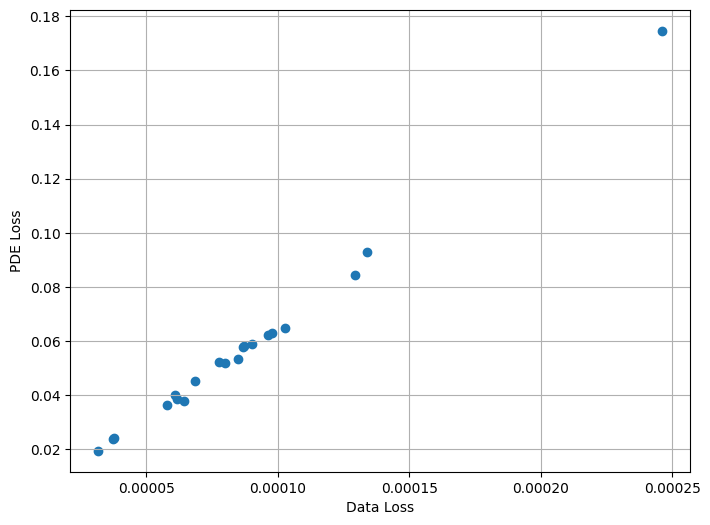

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(data_losses, pde_losses)
plt.xlabel("Data Loss")
plt.ylabel("PDE Loss")
plt.grid()
plt.savefig("data_loss_vs_pde_loss.jpg", dpi=250)
plt.show()

We can see that there is indeed a correlation. Now, what happens if we train a Neural Network on the PDE Loss directly?

In [25]:
def pde_train(model, n_steps, loss_fn=pde_loss, bar=True):
    optimizer = optim.Adam(model.parameters(), lr=5e-3)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=200, T_mult=2, eta_min=1e-5)
    if bar:
        pbar = tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
    for i in pbar:
        optimizer.zero_grad()
        x = (torch.rand(200_000, 1, requires_grad=True)-0.5)*2.5
        loss = loss_fn(model, x.to(device))
        loss.backward()
        optimizer.step()
        lr_scheduler.step(loss)
        if bar:
            pbar.set_description(f"Loss: {loss.item():.5e}")
    return loss

In [26]:
n3 = NetworkBC().to(device)
pde_train(n3, n_steps)

  0%|          | 0/500 [00:00<?, ?it/s]

tensor(0.0011, device='mps:0', grad_fn=<MeanBackward0>)

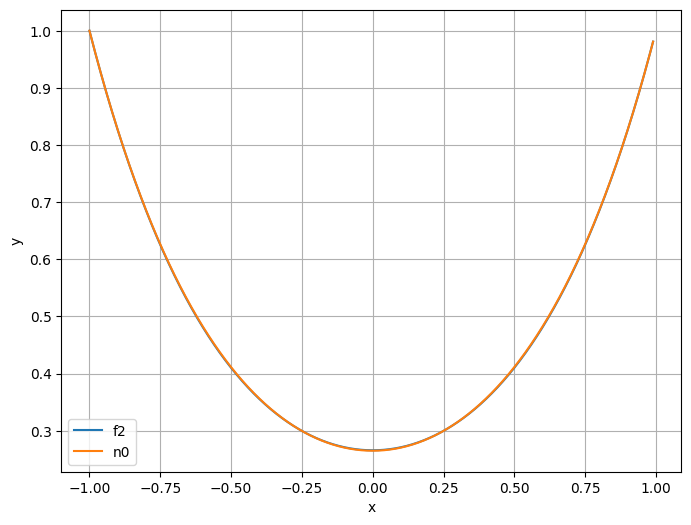

In [27]:
plot(n3.cpu())

We measure the data loss:

In [28]:
n3.to(device)
x = ((torch.rand(200_000, 1)-0.5)*2.5).to(device)
print(f"Data Loss: {loss_fn(n3(x).cpu(), f2(x.cpu())).item():.4e}")

Data Loss: 5.3890e-07


We compare the PDE Loss and the Data Loss of both approaches, on multiple experiments:

In [29]:
data_losses_pde, pde_losses_pde = [], []
for _ in tqdm(range(20)):
    net = NetworkBC().to(device)
    pde_train(net, n_steps, bar=False)
    x = ((torch.rand(200_000, 1)-0.5)*2.5).to(device)
    data_losses_pde.append(loss_fn(net(x).cpu(), f2(x.cpu())).item())
    pde_losses_pde.append(pde_loss(net, torch.arange(-1, 1, 0.01, requires_grad=True, device=device).unsqueeze(1)).item())

  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(pd.DataFrame({"Trained On Data, Data Loss": data_losses,
                         "Trained On PDE, Data Loss": data_losses_pde}))
plt.grid()
plt.show()
plt.figure(figsize=(7, 5))
sns.boxplot(pd.DataFrame({"Trained On Data, PDE Loss": pde_losses,
                         "Trained On PDE, PDE Loss": pde_losses_pde}))
plt.grid()
plt.show()

Up to now, we only approximate one unique solution, because of the BC enforcing term. Rather, we can pick, each time, a random initial condition (of one point $(x_0, y_0)$), to escape from the trivial zero-solution. To enforce this unique point, we have to multply the Neural Network output by a function that vanishes only on this chosen point, as an example, $n_0(x)(x-x_0)+y_0$. We can then study the distribution of the PDE Loss for those approximated solution. 

In [16]:
class Network(nn.Module):
    def __init__(self, width=16):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        
    def forward(self, x, x_0, y_0):
        return self.l1(x) * (x-x_0) + y_0

In [24]:
def pde_loss_unique_bc(model, x, x_0, y_0):
    x = x.requires_grad_(True)
    y_hat = model(x, x_0, y_0)
    y_prime = torch.autograd.grad(y_hat, x, grad_outputs=torch.ones_like(y_hat), create_graph=True)[0]
    y_prime_prime = torch.autograd.grad(y_prime, x, grad_outputs=torch.ones_like(y_prime), create_graph=True)[0]
    loss = torch.mean((y_prime_prime - k**2 * y_hat) ** 2)
    return loss
    
def pde_train_unique_bc(model, n_steps, x_0, y_0, bar=True):
    optimizer = optim.Adam(model.parameters(), lr=5e-3)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=200, T_mult=2, eta_min=1e-5)
    if bar:
        pbar = tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
    for i in pbar:
        optimizer.zero_grad()
        x = (torch.rand(200_000, 1, requires_grad=True)-0.5)*2.5
        loss = pde_loss_unique_bc(model, x.to(device), x_0.to(device), y_0.to(device))
        loss.backward()
        optimizer.step()
        lr_scheduler.step(loss)
        if bar:
            pbar.set_description(f"Loss: {loss.item():.5e}")
    return loss

In [25]:
n_steps=100

In [26]:
n4 = Network().to(device)
x_0 = ((torch.rand(1, 1)-0.5)*3).to(device)
y_0 = ((torch.rand(1, 1))*3).to(device)
print(x_0, y_0)
pde_train_unique_bc(n4, n_steps, x_0, y_0)

tensor([[-0.0953]], device='mps:0') tensor([[1.4618]], device='mps:0')


  0%|          | 0/100 [00:00<?, ?it/s]

tensor(1.4043, device='mps:0', grad_fn=<MeanBackward0>)

We design the general reference solution function, for one fixed point $(x_0, y_0)$:

In [27]:
def f(x, x0, y0, c1):
    return y0 * torch.exp(k * (x - x0)) + c1 * (torch.exp(k * x) - torch.exp(k * (2 * x0 - x)))

We can also compute the closest analytically correct solution to the Network, to compute the data loss with the closest exact solution.

$\argmin_{c_1} \sum_x c_1 B_x + A_x - \hat{y}$

In [47]:
def compute_c1(model, x_0, y_0, n_points=10000):
    x = torch.linspace(-1, 1, n_points).to(device)
    with torch.no_grad():
        y_hat = model(x.unsqueeze(-1), x_0.to(device), y_0.to(device)).squeeze()
    A = y_0 * torch.exp(k * (x - x_0))
    B = torch.exp(k * x) - torch.exp(k * (2 * x_0 - x))
    residual = y_hat - A
    c1 = (B * residual).sum() / (B * B).sum()
    return c1.item()

In [48]:
def plot_unique_bc(model, x_0, y_0):
    x = torch.arange(-1, 1, 0.01).to(device)
    y_hat = model(x.unsqueeze(1), x_0, y_0).squeeze().detach().cpu()
    y2 = f(x.unsqueeze(1), x_0, y_0, compute_c1(n4, x_0, y_0)).squeeze().detach()
    plt.figure(figsize=(8, 6))
    plt.plot(x.detach().cpu(), y2.detach().cpu(), label="f")
    plt.plot(x.detach().cpu(), y_hat.detach().cpu(), label="n0")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

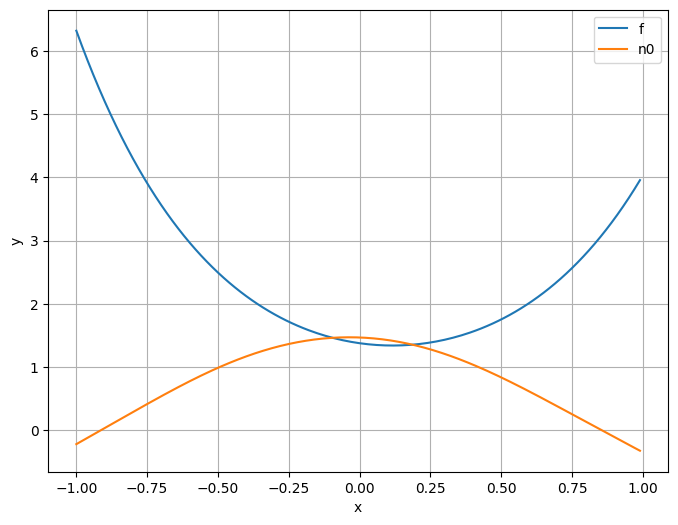

In [49]:
plot_unique_bc(n4, x_0, y_0)

Now, let's see the distribution of the the PDE losses and Data losses for different initial conditions. 

In [38]:
n_points = 15
data_losses_heatmap = np.zeros((n_points, n_points))
pde_losses_heatmap = np.zeros((n_points, n_points))
for i in tqdm(range(n_points)):
    for j in range(n_points):
        n = Network().to(device)
        x_0, y_0 = torch.tensor([[(3*i/n_points)-1]]), torch.tensor([[3*j/n_points]])
        pde_train_unique_bc(n, n_steps, x_0, y_0, bar=False)
        x = (torch.rand(200_000, 1, requires_grad=True)-0.5)*2.5
        data_losses_heatmap[i, j] = loss_fn(n(x.to(device), x_0.to(device), y_0.to(device)).cpu(), f(x.cpu(), x_0, y_0, compute_c1(n.to(device), x_0.to(device), y_0.to(device)))).item()
        pde_losses_heatmap[i, j] = pde_loss_unique_bc(n.to(device), x.to(device), x_0.to(device), y_0.to(device)).item()

  0%|          | 0/10 [00:00<?, ?it/s]

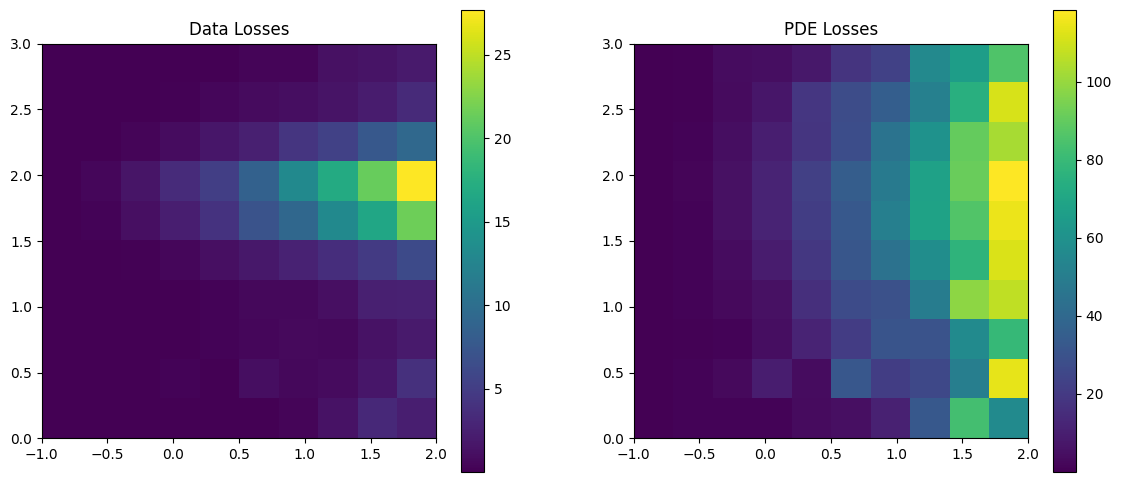

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6 ))
a = ax[0].imshow(data_losses_heatmap, extent=(-1, 2, 0, 3))
plt.colorbar(a)
a = ax[1].imshow(pde_losses_heatmap, extent=(-1, 2, 0, 3))
plt.colorbar(a)
ax[0].set_title("Data Losses")
ax[1].set_title("PDE Losses")
plt.show()

In [40]:
x0_slider = widgets.FloatSlider(value=-1.5, min=-3.0, max=3.0, step=0.1,description='x₀:', continuous_update=False,style={'description_width': 'initial'},layout=widgets.Layout(width='400px'))
y0_slider = widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1,description='y₀:', continuous_update=False,style={'description_width': 'initial'},layout=widgets.Layout(width='400px'))
out = widgets.Output()

def run_and_plot(x0_val, y0_val):
    with out:
        out.clear_output(wait=True)
        x_0 = torch.tensor([[x0_val]])
        y_0 = torch.tensor([[y0_val]])
        n = Network().to(device)
        pde_train_unique_bc(n, n_steps, x_0, y_0, bar=False)
        x = torch.arange(-1, 1, 0.01).unsqueeze(1).to(device)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(x.cpu().numpy(),n(x, x_0.to(device), y_0.to(device)).detach().cpu().numpy(),label='Network output')
        ax.plot(x.cpu().numpy(),f(x.cpu(), x_0, y_0, compute_c1(n.to(device), x_0.to(device), y_0.to(device))).detach().cpu().numpy(),label='Analytical f', linestyle='--')
        ax.set_title(f'x₀ = {x0_val:.2f},  y₀ = {y0_val:.2f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

interactive_plot = widgets.interactive_output(run_and_plot,{'x0_val': x0_slider, 'y0_val': y0_slider})
display(widgets.VBox([widgets.HBox([x0_slider, y0_slider]),out]))
run_and_plot(x0_slider.value, y0_slider.value)